# 1. **Problem Statement -**
X Education is an online education company that generates a large number of leads through various marketing channels such as website visits, search engines, advertisements, referrals, and social media. While many users show interest in the company’s courses, only a small percentage eventually become paying customers.

 Currently, the sales team contacts leads manually without knowing which prospects are more likely to convert. This results in significant time and effort being spent on leads that may never become customers.

 The company requires a data-driven solution to identify high-quality leads so that the sales team can prioritize their efforts toward the most promising prospects, ultimately improving conversion rates and optimizing resource utilization.

# 2. **Business Understanding -**
- Lead scoring is the process of assigning a value or score to each lead based on the likelihood that the lead will convert into a paying customer.

- Instead of treating every lead equally, the business aims to identify high-potential leads using historical customer data and behavioral attributes. A predictive model can help the sales team focus on leads that have the highest probability of conversion, leading to better efficiency and increased revenue.

# 3. **Machine Learning Objective -**
The objective of this project is to develop a supervised binary classification model that predicts whether a lead will convert into a customer based on the information available during lead generation.

The target variable for this project is:

Converted

* 1 → Lead Converted
* 0 → Lead Not Converted

The developed model should accurately classify leads while maintaining a balance between Precision, Recall, F1-Score, and ROC-AUC, enabling the business to make informed decisions for lead prioritization.

#4. **Import Required Libraries -**


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
plt.style.use('ggplot')
sns.set_palette('Set2')

print("Libraries imported successfully.")

Libraries imported successfully.


#5. **Dataset Loading & Initial Inspection -**

##5.1.  Load the Dataset :

In [2]:
df = pd.read_csv("Lead Scoring.csv")
print("Dataset loaded successfully!")

Dataset loaded successfully!


##5.2. Display Dataset Shape :

In [3]:
print(f"Number of Rows    : {df.shape[0]}")
print(f"Number of Columns : {df.shape[1]}")

Number of Rows    : 9240
Number of Columns : 37


##5.3. Display dataset info :

In [4]:
df.head()

,Prospect ID,Lead Number,Lead Origin,Lead Source,Do Not Email,Do Not Call,Converted,TotalVisits,Total Time Spent on Website,Page Views Per Visit,Last Activity,Country,Specialization,How did you hear about X Education,What is your current occupation,What matters most to you in choosing a course,Search,Magazine,Newspaper Article,X Education Forums,Newspaper,Digital Advertisement,Through Recommendations,Receive More Updates About Our Courses,Tags,Lead Quality,Update me on Supply Chain Content,Get updates on DM Content,Lead Profile,City,Asymmetrique Activity Index,Asymmetrique Profile Index,Asymmetrique Activity Score,Asymmetrique Profile Score,I agree to pay the amount through cheque,A free copy of Mastering The Interview,Last Notable Activity
0,7927b2df-8bba-4d29-b9a2-b6e0beafe620,660737,API,Olark Chat,No,No,0,0.0,0,0.0,Page Visited on Website,NaN,Select,Select,Unemployed,Better Career Prospects,No,No,No,No,No,No,No,No,Interested in other courses,Low in Relevance,No,No,Select,Select,02.Medium,02.Medium,15.0,15.0,No,No,Modified
1,2a272436-5132-4136-86fa-dcc88c88f482,660728,API,Organic Search,No,No,0,5.0,674,2.5,Email Opened,India,Select,Select,Unemployed,Better Career Prospects,No,No,No,No,No,No,No,No,Ringing,NaN,No,No,Select,Select,02.Medium,02.Medium,15.0,15.0,No,No,Email Opened
2,8cc8c611-a219-4f35-ad23-fdfd2656bd8a,660727,Landing Page Submission,Direct Traffic,No,No,1,2.0,1532,2.0,Email Opened,India,Business Administration,Select,Student,Better Career Prospects,No,No,No,No,No,No,No,No,Will revert after reading the email,Might be,No,No,Potential Lead,Mumbai,02.Medium,01.High,14.0,20.0,No,Yes,Email Opened
3,0cc2df48-7cf4-4e39-9de9-19797f9b38cc,660719,Landing Page Submission,Direct Traffic,No,No,0,1.0,305,1.0,Unreachable,India,Media and Advertising,Word Of Mouth,Unemployed,Better Career Prospects,No,No,No,No,No,No,No,No,Ringing,Not Sure,No,No,Select,Mumbai,02.Medium,01.High,13.0,17.0,No,No,Modified
4,3256f628-e534-4826-9d63-4a8b88782852,660681,Landing Page Submission,Google,No,No,1,2.0,1428,1.0,Converted to Lead,India,Select,Other,Unemployed,Better Career Prospects,No,No,No,No,No,No,No,No,Will revert after reading the email,Might be,No,No,Select,Mumbai,02.Medium,01.High,15.0,18.0,No,No,Modified


In [5]:
df.tail()

,Prospect ID,Lead Number,Lead Origin,Lead Source,Do Not Email,Do Not Call,Converted,TotalVisits,Total Time Spent on Website,Page Views Per Visit,Last Activity,Country,Specialization,How did you hear about X Education,What is your current occupation,What matters most to you in choosing a course,Search,Magazine,Newspaper Article,X Education Forums,Newspaper,Digital Advertisement,Through Recommendations,Receive More Updates About Our Courses,Tags,Lead Quality,Update me on Supply Chain Content,Get updates on DM Content,Lead Profile,City,Asymmetrique Activity Index,Asymmetrique Profile Index,Asymmetrique Activity Score,Asymmetrique Profile Score,I agree to pay the amount through cheque,A free copy of Mastering The Interview,Last Notable Activity
9235,19d6451e-fcd6-407c-b83b-48e1af805ea9,579564,Landing Page Submission,Direct Traffic,Yes,No,1,8.0,1845,2.67,Email Marked Spam,Saudi Arabia,IT Projects Management,Select,Unemployed,Better Career Prospects,No,No,No,No,No,No,No,No,Will revert after reading the email,High in Relevance,No,No,Potential Lead,Mumbai,02.Medium,01.High,15.0,17.0,No,No,Email Marked Spam
9236,82a7005b-7196-4d56-95ce-a79f937a158d,579546,Landing Page Submission,Direct Traffic,No,No,0,2.0,238,2.00,SMS Sent,India,Media and Advertising,Select,Unemployed,Better Career Prospects,No,No,No,No,No,No,No,No,wrong number given,Might be,No,No,Potential Lead,Mumbai,02.Medium,01.High,14.0,19.0,No,Yes,SMS Sent
9237,aac550fe-a586-452d-8d3c-f1b62c94e02c,579545,Landing Page Submission,Direct Traffic,Yes,No,0,2.0,199,2.00,SMS Sent,India,Business Administration,Select,Unemployed,Better Career Prospects,No,No,No,No,No,No,No,No,invalid number,Not Sure,No,No,Potential Lead,Mumbai,02.Medium,01.High,13.0,20.0,No,Yes,SMS Sent
9238,5330a7d1-2f2b-4df4-85d6-64ca2f6b95b9,579538,Landing Page Submission,Google,No,No,1,3.0,499,3.00,SMS Sent,India,Human Resource Management,Online Search,NaN,NaN,No,No,No,No,No,No,No,No,NaN,NaN,No,No,NaN,Other Metro Cities,02.Medium,02.Medium,15.0,16.0,No,No,SMS Sent
9239,571b5c8e-a5b2-4d57-8574-f2ffb06fdeff,579533,Landing Page Submission,Direct Traffic,No,No,1,6.0,1279,3.00,SMS Sent,Bangladesh,Supply Chain Management,Select,Unemployed,Better Career Prospects,No,No,No,No,No,No,No,No,Will revert after reading the email,Might be,No,No,Potential Lead,Other Cities,02.Medium,01.High,15.0,18.0,No,Yes,Modified


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9240 entries, 0 to 9239
Data columns (total 37 columns):
 #   Column                                         Non-Null Count  Dtype  
---  ------                                         --------------  -----  
 0   Prospect ID                                    9240 non-null   object 
 1   Lead Number                                    9240 non-null   int64  
 2   Lead Origin                                    9240 non-null   object 
 3   Lead Source                                    9204 non-null   object 
 4   Do Not Email                                   9240 non-null   object 
 5   Do Not Call                                    9240 non-null   object 
 6   Converted                                      9240 non-null   int64  
 7   TotalVisits                                    9103 non-null   float64
 8   Total Time Spent on Website                    9240 non-null   int64  
 9   Page Views Per Visit                           9103 

In [7]:
# statistical summary
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Prospect ID,9240,9240,571b5c8e-a5b2-4d57-8574-f2ffb06fdeff,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Lead Number,9240.0,NaN,NaN,NaN,617188.435606,23405.995698,579533.0,596484.5,615479.0,637387.25,660737.0
Lead Origin,9240,5,Landing Page Submission,4886,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Lead Source,9204,21,Google,2868,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Do Not Email,9240,2,No,8506,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Do Not Call,9240,2,No,9238,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Converted,9240.0,NaN,NaN,NaN,0.38539,0.486714,0.0,0.0,0.0,1.0,1.0
TotalVisits,9103.0,NaN,NaN,NaN,3.445238,4.854853,0.0,1.0,3.0,5.0,251.0
Total Time Spent on Website,9240.0,NaN,NaN,NaN,487.698268,548.021466,0.0,12.0,248.0,936.0,2272.0
Page Views Per Visit,9103.0,NaN,NaN,NaN,2.36282,2.161418,0.0,1.0,2.0,3.0,55.0


##5.4.  Missing Values :

In [8]:
# Missing Values Analysis

missing_df = pd.DataFrame({
    'Missing Values': df.isnull().sum(),
    'Missing Percentage (%)': round((df.isnull().sum() / len(df)) * 100, 2)
})

missing_df = missing_df[missing_df['Missing Values'] > 0]
missing_df = missing_df.sort_values(by='Missing Percentage (%)', ascending=False)

missing_df

,Missing Values,Missing Percentage (%)
Lead Quality,4767,51.59
Asymmetrique Profile Score,4218,45.65
Asymmetrique Activity Index,4218,45.65
Asymmetrique Activity Score,4218,45.65
Asymmetrique Profile Index,4218,45.65
Tags,3353,36.29
What matters most to you in choosing a course,2709,29.32
Lead Profile,2709,29.32
What is your current occupation,2690,29.11
Country,2461,26.63


##5.5. Check Duplicate Records :

In [9]:
# Check Duplicate Records
duplicates = df.duplicated().sum()

print(f"Number of duplicate rows: {duplicates}")

Number of duplicate rows: 0


##5.6. Number Unique Values :

In [10]:
# Number of Unique Values in Each Column
unique_df = pd.DataFrame({
    'Data Type': df.dtypes,
    'Unique Values': df.nunique()
})

unique_df = unique_df.sort_values(by='Unique Values')

unique_df

,Data Type,Unique Values
Get updates on DM Content,object,1
Update me on Supply Chain Content,object,1
Receive More Updates About Our Courses,object,1
Magazine,object,1
I agree to pay the amount through cheque,object,1
Do Not Call,object,2
Do Not Email,object,2
Converted,int64,2
Search,object,2
Newspaper Article,object,2


## Observations :

- The dataset contains **9,240 records** and **37 features**, providing sufficient data for building a machine learning classification model.

- The target variable **`Converted`** is already available in binary format (0 = Not Converted, 1 = Converted), making this a supervised binary classification problem.

- The dataset consists of **30 categorical features**, **4 floating-point numerical features**, and **3 integer features**, indicating that categorical data preprocessing will be a significant part of the workflow.

- Several features contain missing values. The highest missing percentages are observed in **Lead Quality (51.59%)**, followed by the **Asymmetrique** features (45.65%) and **Tags (36.29%)**.

- No duplicate records were found in the dataset, indicating that each row represents a unique lead.

- Five columns (`Magazine`, `Receive More Updates About Our Courses`, `Update me on Supply Chain Content`, `Get updates on DM Content`, and `I agree to pay the amount through cheque`) contain only a single unique value, suggesting they may not contribute meaningful information to model training.

- The columns **Prospect ID** and **Lead Number** contain unique values for every record, indicating that they are likely identifier variables rather than predictive features.

- Most categorical features have a relatively small number of unique categories, making them suitable for encoding during the preprocessing stage.

- Based on the initial inspection, the dataset appears suitable for further preprocessing, exploratory data analysis, and feature engineering.

# 6. **Data Quality Assessment -**

In [11]:
# Verify Identifier Columns
identifier_cols = ['Prospect ID', 'Lead Number']

for col in identifier_cols:
    print(f"{col}: {df[col].nunique()} unique values out of {len(df)} records")

Prospect ID: 9240 unique values out of 9240 records
Lead Number: 9240 unique values out of 9240 records


In [12]:
# Identify Constant Columns
constant_cols = [col for col in df.columns if df[col].nunique() == 1]
print(f"Number of Constant Columns: {len(constant_cols)}\n")

for col in constant_cols:
    print(f"{col} --> {df[col].unique()[0]}")

Number of Constant Columns: 5

Magazine --> No
Receive More Updates About Our Courses --> No
Update me on Supply Chain Content --> No
Get updates on DM Content --> No
I agree to pay the amount through cheque --> No


In [13]:
# Check for 'Select' Placeholder Values
select_counts = {}

for col in df.select_dtypes(include='object').columns:
    count = (df[col] == 'Select').sum()
    if count > 0:
        select_counts[col] = count

select_df = pd.DataFrame(
    select_counts.items(),
    columns=['Column', "'Select' Count"]
).sort_values(by="'Select' Count", ascending=False)

select_df

,Column,'Select' Count
1,How did you hear about X Education,5043
2,Lead Profile,4146
3,City,2249
0,Specialization,1942


## Observation :
- Four categorical features contain the placeholder value **"Select"**, which represents unselected or missing information rather than a valid category.

- The highest occurrence of `"Select"` is observed in **How did you hear about X Education (5043 records)**.

- Since `"Select"` does not represent meaningful information, these values will be treated as missing values during the data cleaning stage.

In [14]:
# Load Data Dictionary
data_dict = pd.read_excel("Leads Data Dictionary.xlsx")
data_dict

,Unnamed: 0,Unnamed: 1,Unnamed: 2
0,NaN,NaN,NaN
1,NaN,Variables,Description
2,NaN,Prospect ID,A unique ID with which the customer is identif...
3,NaN,Lead Number,A lead number assigned to each lead procured.
4,NaN,Lead Origin,The origin identifier with which the customer ...
5,NaN,Lead Source,"The source of the lead. Includes Google, Organ..."
6,NaN,Do Not Email,An indicator variable selected by the customer...
7,NaN,Do Not Call,An indicator variable selected by the customer...
8,NaN,Converted,The target variable. Indicates whether a lead ...
9,NaN,TotalVisits,The total number of visits made by the custome...


In [15]:
data_dict.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39 entries, 0 to 38
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  0 non-null      float64
 1   Unnamed: 1  38 non-null     object 
 2   Unnamed: 2  30 non-null     object 
dtypes: float64(1), object(2)
memory usage: 1.0+ KB


In [16]:
data_dict.head(10)

,Unnamed: 0,Unnamed: 1,Unnamed: 2
0,NaN,NaN,NaN
1,NaN,Variables,Description
2,NaN,Prospect ID,A unique ID with which the customer is identif...
3,NaN,Lead Number,A lead number assigned to each lead procured.
4,NaN,Lead Origin,The origin identifier with which the customer ...
5,NaN,Lead Source,"The source of the lead. Includes Google, Organ..."
6,NaN,Do Not Email,An indicator variable selected by the customer...
7,NaN,Do Not Call,An indicator variable selected by the customer...
8,NaN,Converted,The target variable. Indicates whether a lead ...
9,NaN,TotalVisits,The total number of visits made by the custome...


In [17]:
# Data Quality Summary
summary = pd.DataFrame({
    "Data Type": df.dtypes,
    "Missing Values": df.isnull().sum(),
    "Missing (%)": round(df.isnull().sum() * 100 / len(df), 2),
    "Unique Values": df.nunique()
})

summary

,Data Type,Missing Values,Missing (%),Unique Values
Prospect ID,object,0,0.00,9240
Lead Number,int64,0,0.00,9240
Lead Origin,object,0,0.00,5
Lead Source,object,36,0.39,21
Do Not Email,object,0,0.00,2
Do Not Call,object,0,0.00,2
Converted,int64,0,0.00,2
TotalVisits,float64,137,1.48,41
Total Time Spent on Website,int64,0,0.00,1731
Page Views Per Visit,float64,137,1.48,114


## Overall Data Quality Assessment :

- The dataset contains **9,240 observations** and **37 features**.
- No duplicate records were found.
- Two columns (`Prospect ID` and `Lead Number`) are unique identifiers.
- Five columns contain only a single unique value and provide no predictive information.
- Four categorical features contain the placeholder value `"Select"`, which should be treated as missing information during preprocessing.
- Several features contain missing values, with `Lead Quality` having the highest percentage of missing records (51.59%).
- Most categorical variables have low to moderate cardinality, making them suitable for encoding after preprocessing.
- Overall, the dataset is of good quality but requires systematic preprocessing before model development.

# 7. **Exploratory Data Analysis (EDA) -**

## 7.1. Target Variable Analysis :

In [18]:
# Target Variable Distribution
target_counts = df['Converted'].value_counts().sort_index()

target_df = pd.DataFrame({
    'Class': ['Not Converted (0)', 'Converted (1)'],
    'Count': target_counts.values,
    'Percentage (%)': np.round((target_counts.values / len(df)) * 100, 2)
})

target_df

,Class,Count,Percentage (%)
0,Not Converted (0),5679,61.46
1,Converted (1),3561,38.54


In [19]:
# Target Variable Distribution
target_df = (
    df['Converted']
    .value_counts()
    .sort_index()
    .rename_axis('Converted')
    .reset_index(name='Count')
)

target_df['Class'] = target_df['Converted'].map({
    0: 'Not Converted',
    1: 'Converted'
})

target_df['Percentage (%)'] = (
    target_df['Count'] / len(df) * 100
).round(2)

target_df = target_df[['Class', 'Count', 'Percentage (%)']]

target_df

,Class,Count,Percentage (%)
0,Not Converted,5679,61.46
1,Converted,3561,38.54


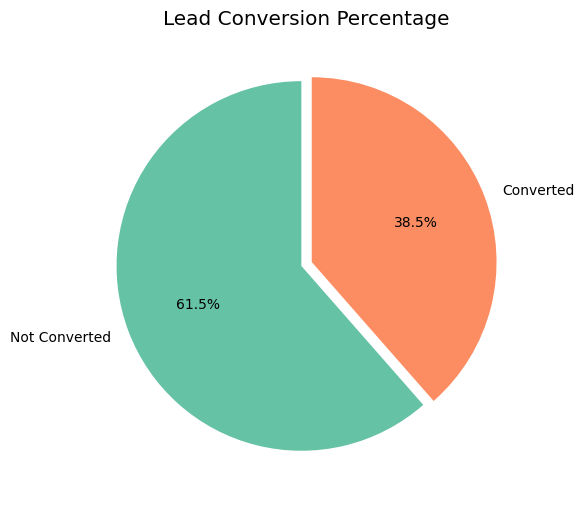

In [20]:
# Target Variable Percentage Distribution
plt.figure(figsize=(6,6))

plt.pie(
    target_counts,
    labels=['Not Converted', 'Converted'],
    autopct='%1.1f%%',
    startangle=90,
    explode=(0.03, 0.03)
)

plt.title('Lead Conversion Percentage')

plt.show()

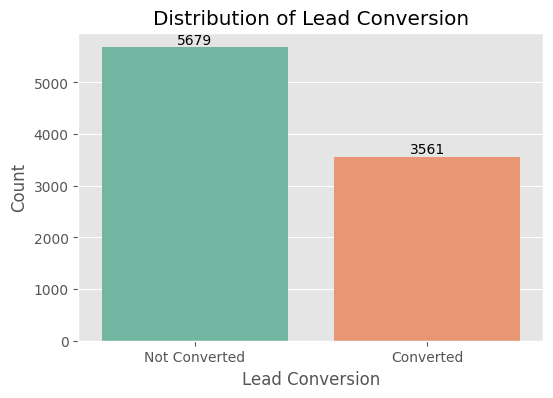

In [21]:
# Target Variable Visualization
plt.figure(figsize=(6,4))

ax = sns.countplot(
    data=df,
    x='Converted',
    palette='Set2'
)

plt.title('Distribution of Lead Conversion')
plt.xlabel('Lead Conversion')
plt.ylabel('Count')

for container in ax.containers:
    ax.bar_label(container)

plt.xticks([0, 1], ['Not Converted', 'Converted'])

plt.show()

## 7.2 Numerical Feature Analysis :

In [22]:
# Identify Numerical Features
numerical_features = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

print("Numerical Features:")
numerical_features

Numerical Features:


['Lead Number',
 'Converted',
 'TotalVisits',
 'Total Time Spent on Website',
 'Page Views Per Visit',
 'Asymmetrique Activity Score',
 'Asymmetrique Profile Score']

In [23]:
# Numerical Predictor Features
numerical_cols = [
    'TotalVisits',
    'Total Time Spent on Website',
    'Page Views Per Visit',
    'Asymmetrique Activity Score',
    'Asymmetrique Profile Score'
]

print("Numerical Predictor Features:")
numerical_cols

Numerical Predictor Features:


['TotalVisits',
 'Total Time Spent on Website',
 'Page Views Per Visit',
 'Asymmetrique Activity Score',
 'Asymmetrique Profile Score']

In [24]:
# Statistical Summary of Numerical Features
df[numerical_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
TotalVisits,9103.0,3.445238,4.854853,0.0,1.0,3.0,5.0,251.0
Total Time Spent on Website,9240.0,487.698268,548.021466,0.0,12.0,248.0,936.0,2272.0
Page Views Per Visit,9103.0,2.362820,2.161418,0.0,1.0,2.0,3.0,55.0
Asymmetrique Activity Score,5022.0,14.306252,1.386694,7.0,14.0,14.0,15.0,18.0
Asymmetrique Profile Score,5022.0,16.344883,1.811395,11.0,15.0,16.0,18.0,20.0


### Observation for Numerical Feature Analysis :

- Five numerical predictor features were identified after excluding the identifier (`Lead Number`) and target (`Converted`) columns.
- `TotalVisits` and `Page Views Per Visit` contain a small number of missing values, whereas the Asymmetrique score features have a significantly higher proportion of missing values.
- `TotalVisits`, `Total Time Spent on Website`, and `Page Views Per Visit` exhibit a wide range of values, indicating the possible presence of outliers.
- `Asymmetrique Activity Score` and `Asymmetrique Profile Score` are bounded within a relatively small range but require missing value treatment before model training.
- Further distribution and outlier analysis is required to better understand the behavior of these numerical variables.

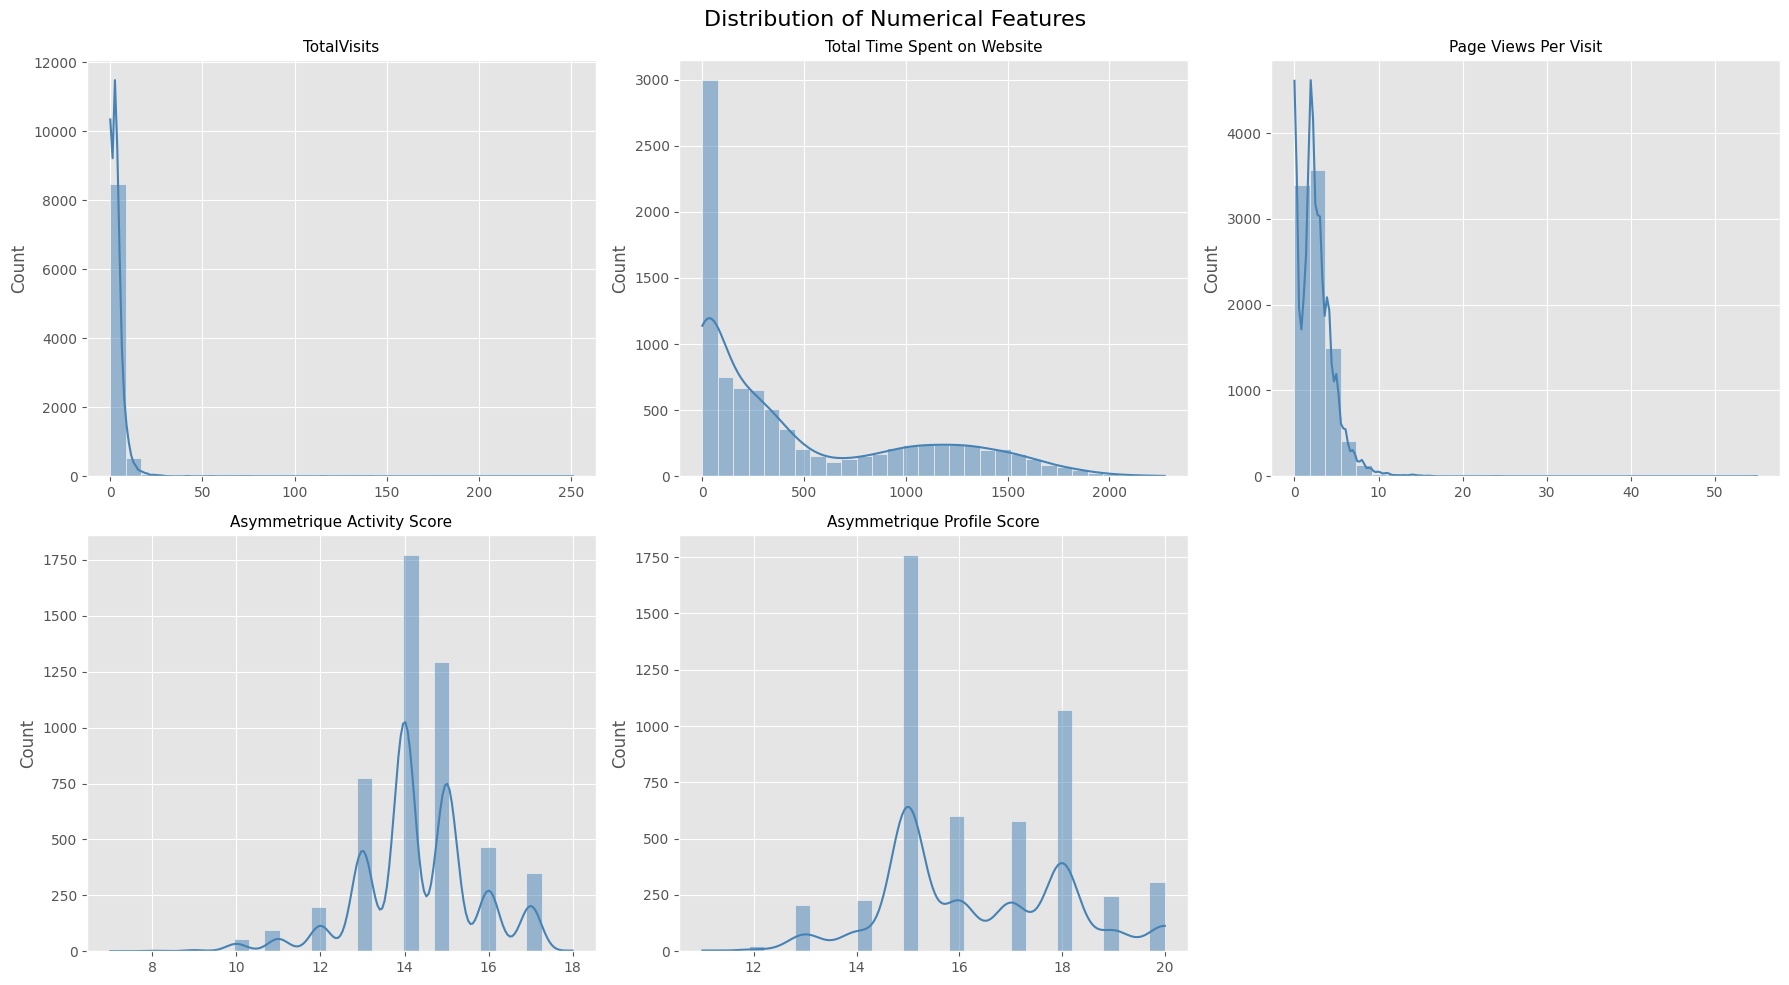

In [25]:
# Distribution of Numerical Features
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    sns.histplot(
        data=df,
        x=col,
        kde=True,
        bins=30,
        ax=axes[i],
        color='steelblue'
    )

    axes[i].set_title(col, fontsize=11)
    axes[i].set_xlabel("")

# Remove the empty subplot
fig.delaxes(axes[-1])

plt.suptitle("Distribution of Numerical Features", fontsize=16)
plt.tight_layout()
plt.show()

### Observation from above plots :

- `TotalVisits` exhibits a highly right-skewed distribution. Most leads have very few website visits, while a small number of leads have exceptionally high visit counts, indicating the presence of potential outliers.

- `Total Time Spent on Website` is also positively skewed. Most users spend relatively less time on the website, whereas a smaller group spends significantly longer durations.

- `Page Views Per Visit` follows a right-skewed distribution with the majority of leads viewing only a few pages per visit. A few observations with unusually high page views suggest possible outliers.

- `Asymmetrique Activity Score` and `Asymmetrique Profile Score` are concentrated within a narrow range of values and exhibit comparatively stable distributions.

- The numerical feature distributions indicate that outlier analysis should be performed before model development.

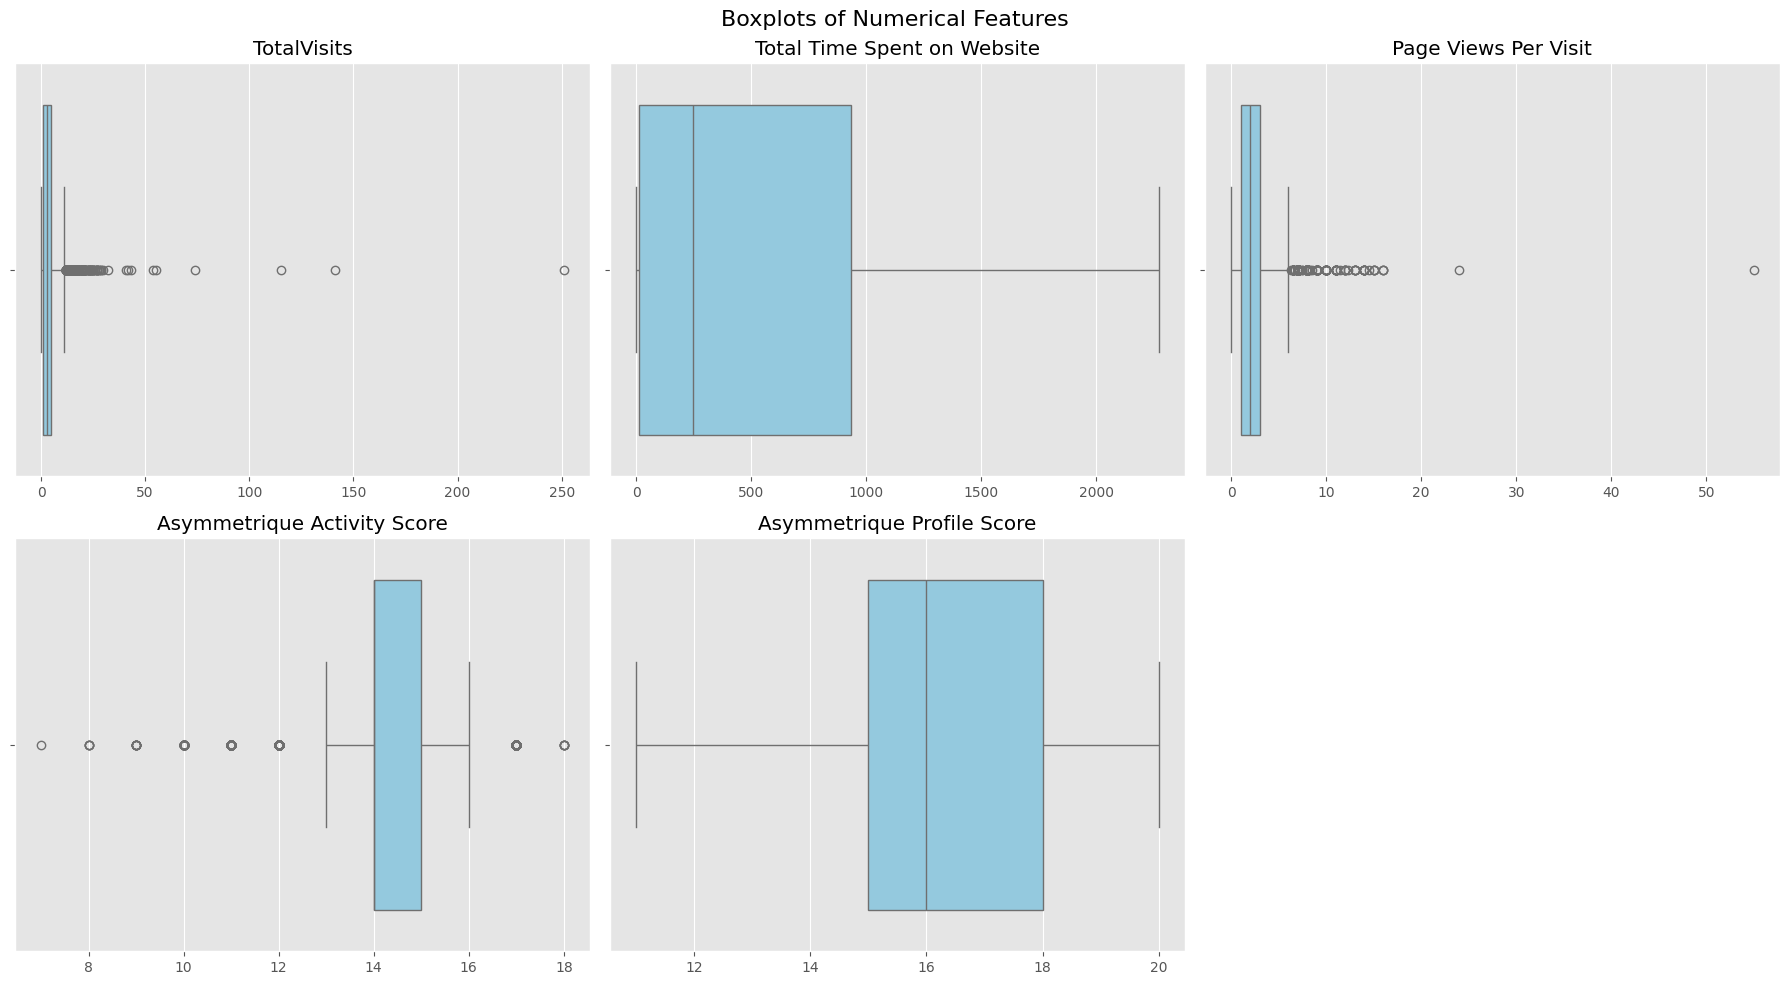

In [26]:
# Outlier Analysis of Numerical Features
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    sns.boxplot(
        x=df[col],
        ax=axes[i],
        color='skyblue'
    )
    axes[i].set_title(col)
    axes[i].set_xlabel("")

# Remove empty subplot
fig.delaxes(axes[-1])

plt.suptitle("Boxplots of Numerical Features", fontsize=16)

plt.tight_layout()

plt.show()

##7.3. Categorical Feature Analysis :

In [27]:
# Identify Categorical Features
categorical_features = df.select_dtypes(include='object').columns.tolist()
print(f"Total Categorical Features: {len(categorical_features)}\n")
categorical_features

Total Categorical Features: 30



['Prospect ID',
 'Lead Origin',
 'Lead Source',
 'Do Not Email',
 'Do Not Call',
 'Last Activity',
 'Country',
 'Specialization',
 'How did you hear about X Education',
 'What is your current occupation',
 'What matters most to you in choosing a course',
 'Search',
 'Magazine',
 'Newspaper Article',
 'X Education Forums',
 'Newspaper',
 'Digital Advertisement',
 'Through Recommendations',
 'Receive More Updates About Our Courses',
 'Tags',
 'Lead Quality',
 'Update me on Supply Chain Content',
 'Get updates on DM Content',
 'Lead Profile',
 'City',
 'Asymmetrique Activity Index',
 'Asymmetrique Profile Index',
 'I agree to pay the amount through cheque',
 'A free copy of Mastering The Interview',
 'Last Notable Activity']

In [28]:
# Categorize Categorical Features
# Already identified earlier
identifier_cols = ['Prospect ID']
constant_cols = [
    'Magazine',
    'Receive More Updates About Our Courses',
    'Update me on Supply Chain Content',
    'Get updates on DM Content',
    'I agree to pay the amount through cheque'
]

# Binary Features
binary_cols = [
    'Do Not Email',
    'Do Not Call',
    'Search',
    'Newspaper Article',
    'X Education Forums',
    'Newspaper',
    'Digital Advertisement',
    'Through Recommendations',
    'A free copy of Mastering The Interview',
    'Receive More Updates About Our Courses',
    'Update me on Supply Chain Content',
    'Get updates on DM Content',
    'I agree to pay the amount through cheque'
]

# Business-important features
business_cols = [
    'Lead Origin',
    'Lead Source',
    'Last Activity',
    'Specialization',
    'What is your current occupation',
    'What matters most to you in choosing a course',
    'Lead Profile',
    'City',
    'Last Notable Activity',
    'Lead Quality',
    'Tags'
]

print("Identifier Columns :", identifier_cols)
print("\nConstant Columns :", constant_cols)
print("\nBinary Features :", binary_cols)
print("\nBusiness Important Features :", business_cols)

Identifier Columns : ['Prospect ID']

Constant Columns : ['Magazine', 'Receive More Updates About Our Courses', 'Update me on Supply Chain Content', 'Get updates on DM Content', 'I agree to pay the amount through cheque']

Binary Features : ['Do Not Email', 'Do Not Call', 'Search', 'Newspaper Article', 'X Education Forums', 'Newspaper', 'Digital Advertisement', 'Through Recommendations', 'A free copy of Mastering The Interview', 'Receive More Updates About Our Courses', 'Update me on Supply Chain Content', 'Get updates on DM Content', 'I agree to pay the amount through cheque']

Business Important Features : ['Lead Origin', 'Lead Source', 'Last Activity', 'Specialization', 'What is your current occupation', 'What matters most to you in choosing a course', 'Lead Profile', 'City', 'Last Notable Activity', 'Lead Quality', 'Tags']


In [29]:
# Summary of Business-Important Categorical Features
for col in business_cols:
    print("=" * 70)
    print(f"{col}")
    print("-" * 70)
    print(f"Unique Values : {df[col].nunique()}")
    print(f"Missing Values: {df[col].isnull().sum()}")

    print("\nTop Categories:")
    print(df[col].value_counts(dropna=False).head(10))
    print("\n")

Lead Origin
----------------------------------------------------------------------
Unique Values : 5
Missing Values: 0

Top Categories:
Lead Origin
Landing Page Submission    4886
API                        3580
Lead Add Form               718
Lead Import                  55
Quick Add Form                1
Name: count, dtype: int64


Lead Source
----------------------------------------------------------------------
Unique Values : 21
Missing Values: 36

Top Categories:
Lead Source
Google              2868
Direct Traffic      2543
Olark Chat          1755
Organic Search      1154
Reference            534
Welingak Website     142
Referral Sites       125
Facebook              55
NaN                   36
bing                   6
Name: count, dtype: int64


Last Activity
----------------------------------------------------------------------
Unique Values : 17
Missing Values: 103

Top Categories:
Last Activity
Email Opened                 3437
SMS Sent                     2745
Olark Chat Co

## 7.4. Selection of Important Categorical Features for Visualization :

The dataset contains several categorical variables; however, visualizing every feature would introduce unnecessary complexity without providing meaningful business insights. Therefore, only the most relevant categorical variables were selected for detailed analysis based on the following criteria:

- **Business relevance:** Features that describe how a lead was acquired, their interaction history, occupation, or background are expected to have a direct influence on lead conversion.
- **Manageable number of categories:** Variables with a reasonable number of unique categories can be interpreted clearly through count plots.
- **Data quality:** Features with extremely high missing values, placeholder values (`Select`), or very high cardinality were excluded from visualization and will instead be handled during the preprocessing stage.

The following categorical features were selected for visualization:

| Feature | Reason for Selection |
|---------|----------------------|
| **Lead Origin** | Identifies the source through which the lead entered the system and provides insights into the effectiveness of different acquisition channels. |
| **Lead Source** | Represents the marketing or referral channel responsible for generating leads and is expected to be an important predictor of conversion. |
| **Last Activity** | Captures the most recent interaction of a lead with the organization, reflecting customer engagement. |
| **Specialization** | Describes the academic or professional specialization of a lead, which may influence their interest in different educational programs. |
| **What is your current occupation** | Indicates the employment status of a lead and helps understand the target customer segment. |
| **Last Notable Activity** | Represents the most significant recent action performed by the lead and provides additional insights into customer engagement behaviour. |

The remaining categorical features were not visualized for one or more of the following reasons:

- They were previously identified as **identifier columns** or **constant columns**.
- They contained an excessively large proportion of missing or placeholder values.
- They exhibited very high cardinality, making count plots difficult to interpret.
- They contributed limited additional business insight during the exploratory analysis and are more appropriately addressed during data preprocessing and feature engineering.

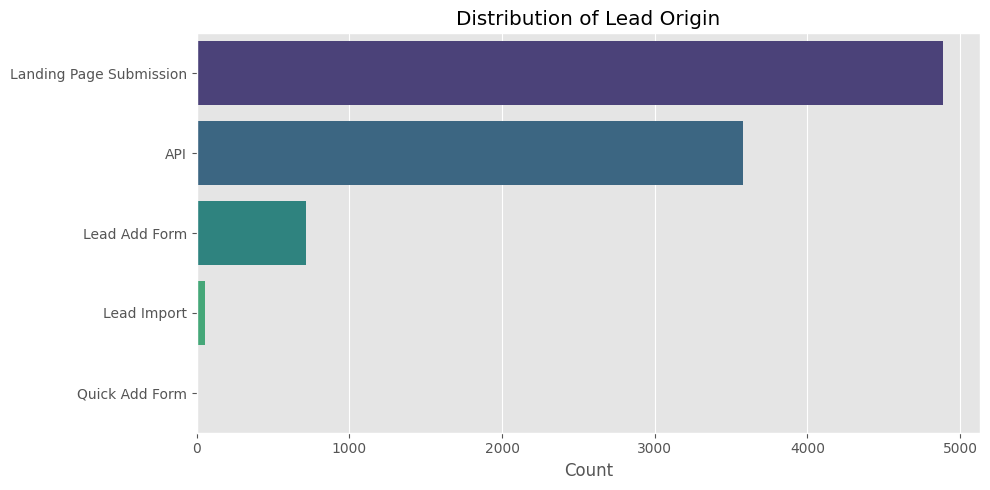

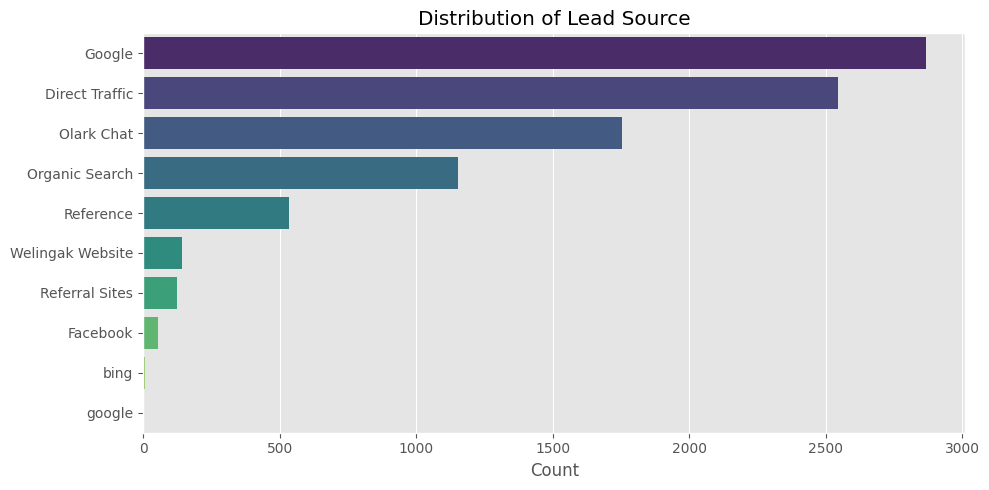

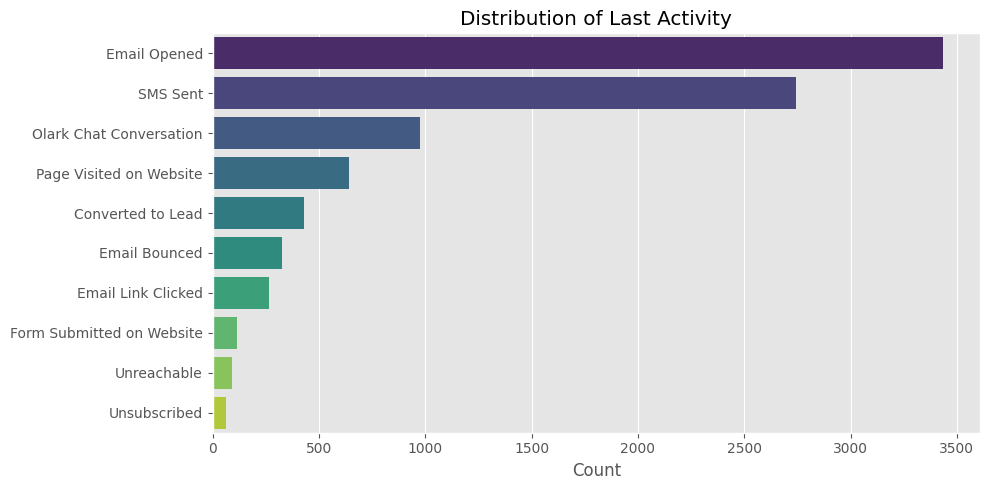

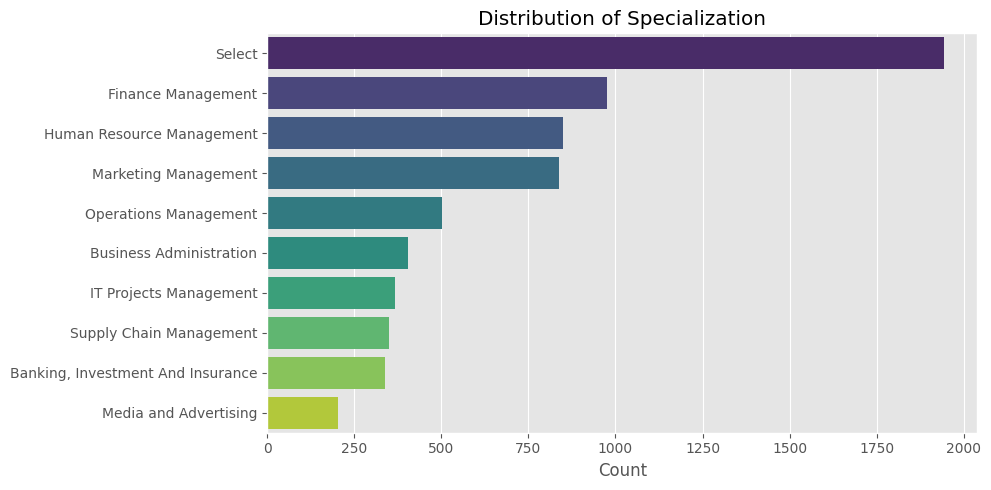

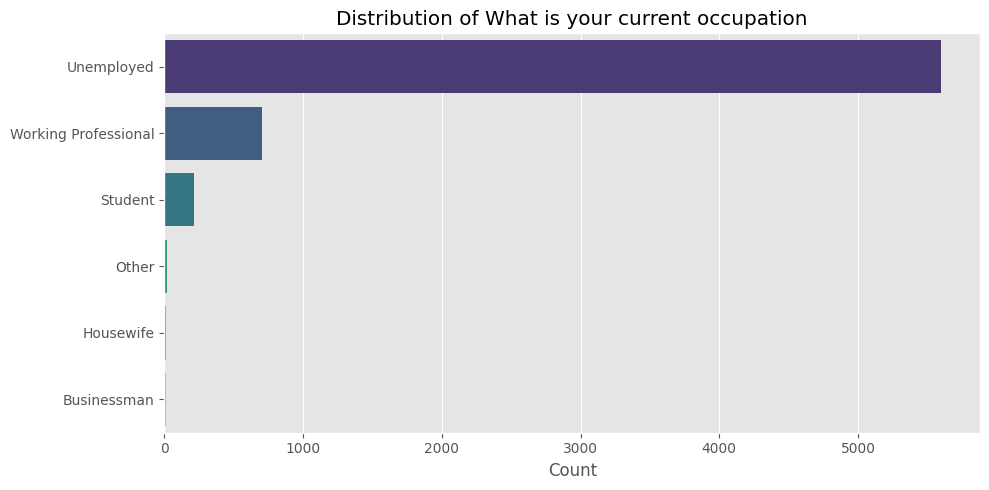

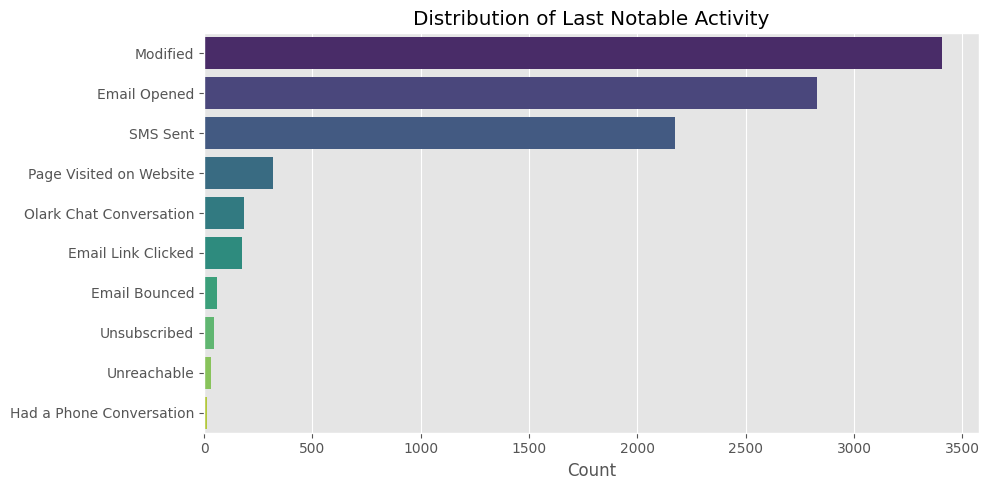

In [30]:
# Distribution of Important Categorical Features
plot_cols = [
    'Lead Origin',
    'Lead Source',
    'Last Activity',
    'Specialization',
    'What is your current occupation',
    'Last Notable Activity'
]

for col in plot_cols:
    plt.figure(figsize=(10,5))

    # Show only top 10 categories for readability
    order = df[col].value_counts().head(10).index
    sns.countplot(
        data=df,
        y=col,
        order=order,
        palette='viridis'
    )

    plt.title(f'Distribution of {col}')
    plt.xlabel("Count")
    plt.ylabel("")
    plt.tight_layout()
    plt.show()

### Observation from above plot :

The important categorical variables reveal several business insights:

- **Lead Origin** is dominated by *Landing Page Submission* and *API*, indicating that most leads are generated through digital channels.
- **Lead Source** is primarily driven by *Google*, *Direct Traffic*, and *Olark Chat*, highlighting the importance of online marketing.
- **Last Activity** shows that most customers interact through *Email Opened* and *SMS Sent*, suggesting that email and SMS campaigns are major engagement channels.
- **Specialization** contains many missing and placeholder (`Select`) values, indicating that data quality improvements will be required before modeling.
- Most leads are **Unemployed**, which may reflect the target audience for educational programs.
- **Last Notable Activity** is largely concentrated around *Modified*, *Email Opened*, and *SMS Sent*, indicating frequent follow-up interactions with prospective leads.

## 7.5. Bivariate Analysis (Feature vs Converted) :

After analyzing the individual distribution of numerical and categorical variables (Univariate Analysis), the next step is to understand **how these features relate to the target variable (`Converted`)**.

Bivariate Analysis examines the relationship between each predictor variable and the target variable to identify patterns associated with lead conversion. This helps answer important business questions such as:

- Which lead acquisition channels generate the highest number of converted leads?
- Which marketing sources are most effective in attracting potential customers?
- Does customer engagement influence the likelihood of conversion?
- Are certain customer profiles or occupations more likely to convert?

The insights obtained from this analysis help identify influential features, support feature selection, and provide valuable business recommendations for improving lead conversion strategies.

In this section, only the most relevant business features are analyzed against the target variable (`Converted`) to avoid redundant visualizations while maintaining meaningful insights.

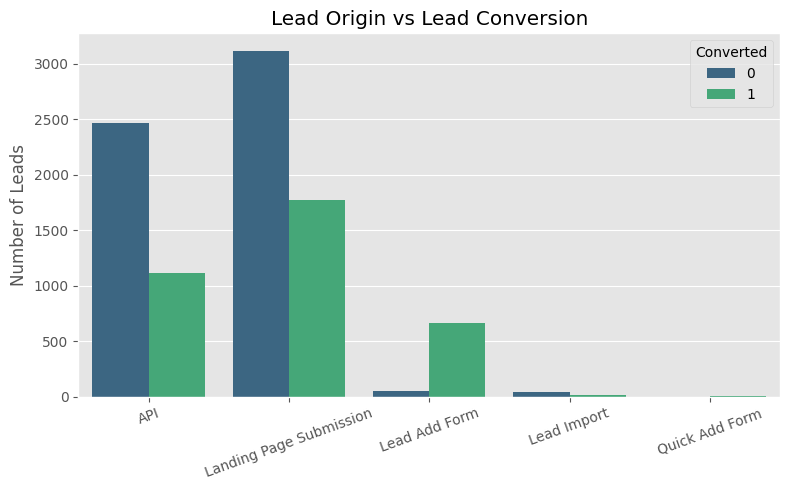

In [31]:
# Lead Origin vs Lead Conversion
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x='Lead Origin',
    hue='Converted',
    palette='viridis'
)

plt.title("Lead Origin vs Lead Conversion")
plt.xticks(rotation=20)
plt.xlabel("")
plt.ylabel("Number of Leads")
plt.tight_layout()
plt.show()

### Observation from above plot :

The relationship between **Lead Origin** and **Lead Conversion** provides insights into the effectiveness of different lead acquisition channels.

- The majority of leads originate from **Landing Page Submission** and **API**, making them the primary acquisition channels.
- Although these channels generate the highest number of leads, their conversion performance should be evaluated by comparing the proportion of converted and non-converted leads rather than the absolute counts.
- Smaller categories such as **Lead Add Form** may generate fewer leads but could potentially exhibit a higher conversion tendency.
- This analysis suggests that the origin of a lead may influence its likelihood of conversion and therefore should be retained as a predictive feature during model building.

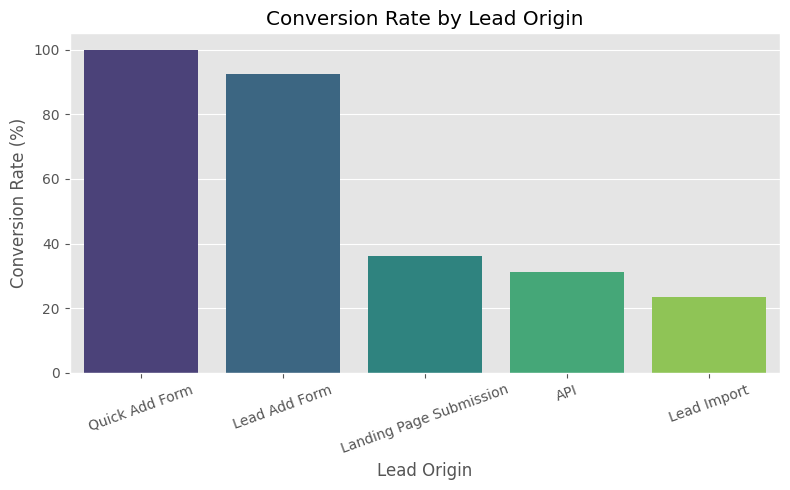

,Converted
Lead Origin,
Quick Add Form,100.00
Lead Add Form,92.48
Landing Page Submission,36.19
API,31.15
Lead Import,23.64


In [32]:
# Conversion Rate by Lead Origin
lead_origin_conversion = (
    df.groupby('Lead Origin')['Converted']
      .mean()
      .sort_values(ascending=False) * 100
)

plt.figure(figsize=(8,5))
sns.barplot(
    x=lead_origin_conversion.index,
    y=lead_origin_conversion.values,
    palette='viridis'
)

plt.title("Conversion Rate by Lead Origin")
plt.xlabel("Lead Origin")
plt.ylabel("Conversion Rate (%)")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()
lead_origin_conversion.round(2)

### Observation from above plot :

The conversion rate differs across lead acquisition channels, indicating that not all lead sources contribute equally to successful conversions.

- Some lead origins generate a **large volume of leads** but achieve a relatively lower conversion rate.
- Other origins contribute fewer leads but demonstrate a **higher likelihood of conversion**, making them valuable from a marketing perspective.
- These findings suggest that marketing efforts should focus not only on increasing lead volume but also on improving lead quality.
- Therefore, **Lead Origin** appears to be an important predictor and will be retained for model development.

In [33]:
# Function to Plot Conversion Rate by Categorical Feature
def plot_conversion_rate(feature):

    conversion_rate = (
        df.groupby(feature)['Converted']
          .mean()
          .sort_values(ascending=False) * 100
    )

    plt.figure(figsize=(9,5))
    sns.barplot(
        x=conversion_rate.index,
        y=conversion_rate.values,
        palette='viridis'
    )

    plt.title(f"Conversion Rate by {feature}")
    plt.xlabel(feature)
    plt.ylabel("Conversion Rate (%)")
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
    display(conversion_rate.round(2).to_frame("Conversion Rate (%)"))

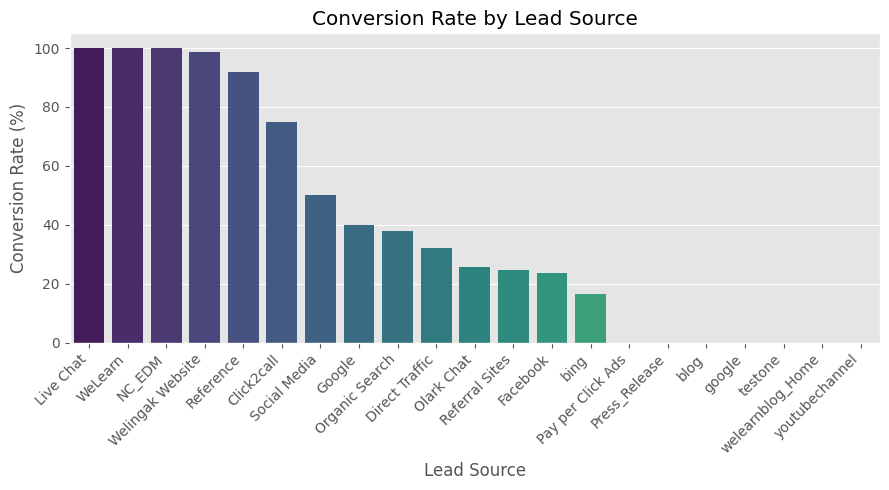

,Conversion Rate (%)
Lead Source,
Live Chat,100.00
WeLearn,100.00
NC_EDM,100.00
Welingak Website,98.59
Reference,91.76
Click2call,75.00
Social Media,50.00
Google,39.99
Organic Search,37.78


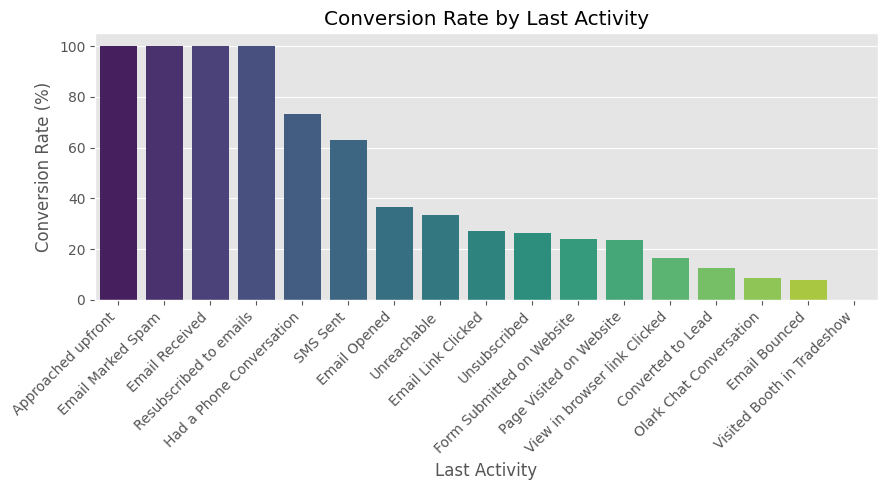

,Conversion Rate (%)
Last Activity,
Approached upfront,100.00
Email Marked Spam,100.00
Email Received,100.00
Resubscribed to emails,100.00
Had a Phone Conversation,73.33
SMS Sent,62.91
Email Opened,36.46
Unreachable,33.33
Email Link Clicked,27.34


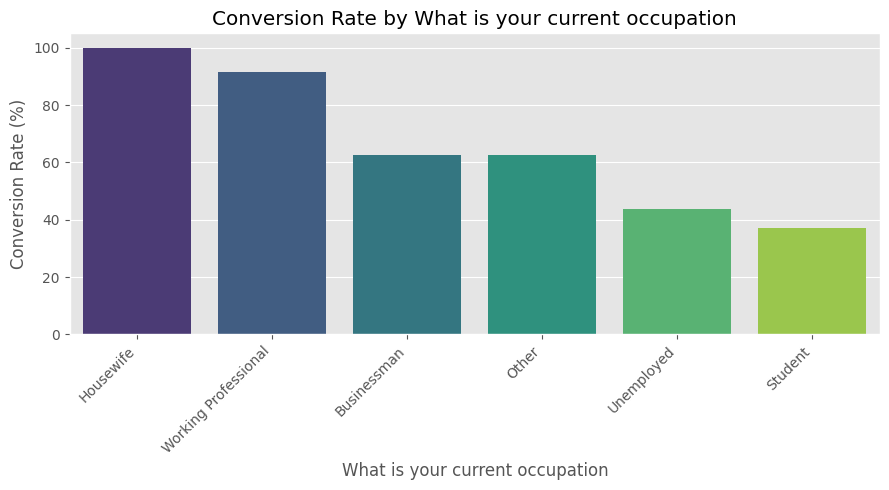

,Conversion Rate (%)
What is your current occupation,
Housewife,100.00
Working Professional,91.64
Businessman,62.50
Other,62.50
Unemployed,43.59
Student,37.14


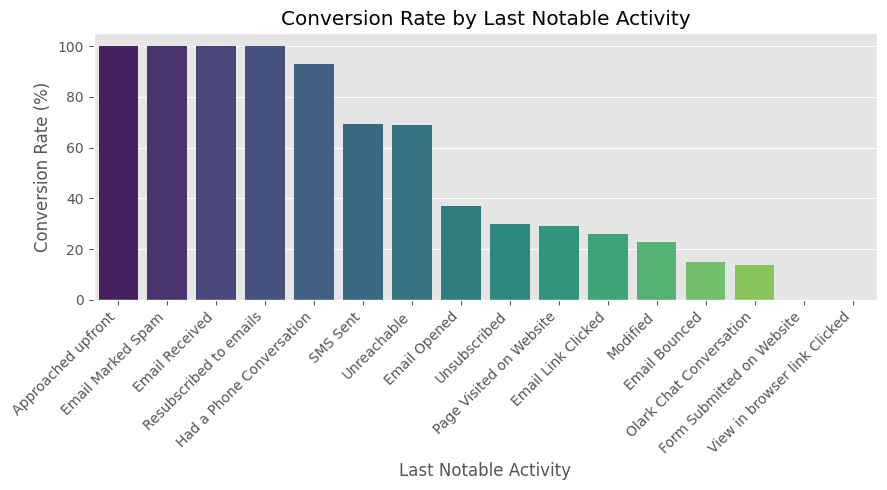

,Conversion Rate (%)
Last Notable Activity,
Approached upfront,100.00
Email Marked Spam,100.00
Email Received,100.00
Resubscribed to emails,100.00
Had a Phone Conversation,92.86
SMS Sent,69.43
Unreachable,68.75
Email Opened,36.93
Unsubscribed,29.79


In [34]:
plot_conversion_rate('Lead Source')

plot_conversion_rate('Last Activity')

plot_conversion_rate('What is your current occupation')

plot_conversion_rate('Last Notable Activity')

### Observation of Conversation Rate :

The conversion rate varies considerably across different categorical features, indicating that customer acquisition channels, engagement history, and occupation influence the likelihood of lead conversion.

Key observations include:

- Certain **Lead Sources** consistently achieve higher conversion rates, suggesting that some marketing channels generate higher-quality leads.
- **Last Activity** demonstrates that customer engagement plays an important role in conversion, with some interaction types showing substantially better outcomes.
- **Current Occupation** indicates that different customer segments exhibit different conversion behaviour, making it a valuable predictor.
- **Last Notable Activity** also shows noticeable differences in conversion rates across categories, highlighting the importance of customer interaction history.

These findings confirm that behavioural and acquisition-related variables are likely to contribute significantly to the predictive performance of the lead scoring model and should be retained during feature engineering and model development.

## 7.5 Correlation Analysis :

Correlation Analysis measures the strength and direction of the linear relationship between numerical variables.

Understanding the correlation among predictor variables helps identify whether two or more features carry similar information. Highly correlated features may introduce redundancy into the model, while weakly correlated features often provide unique information.

Since the Lead Scoring dataset contains only a few numerical predictor variables, a correlation heatmap is sufficient to understand their relationships. This analysis will also help determine whether any feature engineering or multicollinearity treatment is required before model building.

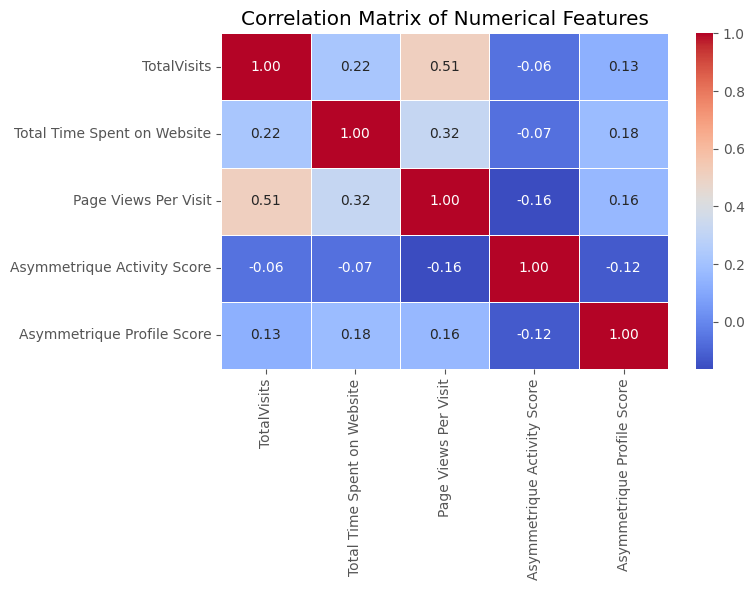

In [35]:
# Correlation Heatmap of Numerical Features
plt.figure(figsize=(8,6))
corr_matrix = df[numerical_cols].corr()
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Matrix of Numerical Features")

plt.tight_layout()
plt.show()

### Observation from Correlation heatmap :

The correlation heatmap indicates the degree of linear relationship among the numerical predictor variables.

- Most numerical features exhibit **low to moderate correlation**, suggesting that they capture different aspects of customer behaviour.
- No pair of numerical features appears to have an extremely high correlation, indicating that severe multicollinearity is unlikely.
- This suggests that all numerical predictor variables can be retained for further preprocessing and model development, subject to additional evaluation during feature engineering.

## 7.6 Overall EDA Summary :

The Exploratory Data Analysis provided valuable insights into the Lead Scoring dataset and established a clear direction for data preprocessing and model development.

### Key Findings -

- The dataset contains **9,240 leads** with **37 features**, including both numerical and categorical variables.
- The target variable (**Converted**) shows a moderate class imbalance, with non-converted leads being more frequent than converted leads.
- Several columns were identified as **identifier** or **constant-value** features that do not contribute to prediction and will be removed during preprocessing.
- Multiple categorical variables contain **"Select"** as a placeholder value, which will be treated as missing data.
- Numerical features such as **Total Visits** and **Page Views Per Visit** exhibit right-skewed distributions and contain outliers.
- Bivariate analysis revealed that customer acquisition channels, engagement history, and occupation have a noticeable influence on lead conversion.
- Correlation analysis showed **no severe multicollinearity** among numerical features.

### Next Steps -

Based on these findings, the next phase will focus on:

- Removing irrelevant features.
- Handling missing values and placeholder entries.
- Encoding categorical variables.
- Scaling numerical features where required.
- Preparing the dataset for machine learning model development.

# 8. **Data Cleaning & Preprocessing -**

The objective of this phase is to transform the raw dataset into a clean and machine learning-ready format.

Based on the findings from the Exploratory Data Analysis (EDA), several preprocessing steps are required, including the removal of irrelevant features, handling missing values, treating placeholder entries, encoding categorical variables, and preparing numerical features for model training.

Each preprocessing step is performed systematically to ensure data quality while preserving meaningful information that contributes to lead conversion prediction.

## 8.1. Feature Selection & Removal of Irrelevant Columns :

In [36]:
# Remove Identifier and Constant Columns
remove_columns = [
    'Prospect ID',
    'Lead Number',
    'Magazine',
    'Receive More Updates About Our Courses',
    'Update me on Supply Chain Content',
    'Get updates on DM Content',
    'I agree to pay the amount through cheque'
]

df = df.drop(columns=remove_columns)
print("Updated Dataset Shape:", df.shape)
print("\nRemaining Features:", len(df.columns))

Updated Dataset Shape: (9240, 30)

Remaining Features: 30


## 8.2. Handling Placeholder Values ("Select") :

In [37]:
# Replace 'Select' with Missing Values
select_columns = [
    'How did you hear about X Education',
    'Lead Profile',
    'City',
    'Specialization'
]

df[select_columns] = df[select_columns].replace('Select', np.nan)
print("Placeholder values successfully converted to missing values.")

Placeholder values successfully converted to missing values.


In [38]:
# Verify Placeholder Removal
for col in select_columns:
    count = (df[col] == 'Select').sum()
    print(f"{col}: {count}")

How did you hear about X Education: 0
Lead Profile: 0
City: 0
Specialization: 0


### Observation :

The placeholder value **"Select"** has been successfully converted into missing values for all relevant categorical features.

This ensures that these entries are now treated as genuine missing data and can be handled consistently during the missing value imputation stage.

## 8.3. Missing Value Assessment :

Before handling missing values, it is important to understand the extent of missing data across the dataset.

Analyzing the number and percentage of missing values helps determine the most appropriate preprocessing strategy for each feature. Depending on the proportion of missing data and the business relevance of the feature, missing values may be imputed or, in some cases, the feature may be removed.

This assessment ensures that preprocessing decisions are data-driven rather than arbitrary.

###8.3.1. Missing Values summary :

In [39]:
# Missing Value Summary
missing_summary = pd.DataFrame({
    'Missing Count': df.isnull().sum(),
    'Missing Percentage': round(df.isnull().mean() * 100, 2)
})

missing_summary = (
    missing_summary[missing_summary['Missing Count'] > 0]
    .sort_values(by='Missing Percentage', ascending=False)
)

missing_summary

,Missing Count,Missing Percentage
How did you hear about X Education,7250,78.46
Lead Profile,6855,74.19
Lead Quality,4767,51.59
Asymmetrique Activity Index,4218,45.65
Asymmetrique Profile Index,4218,45.65
Asymmetrique Profile Score,4218,45.65
Asymmetrique Activity Score,4218,45.65
City,3669,39.71
Specialization,3380,36.58
Tags,3353,36.29


In [40]:
# Remove Features with Excessive Missing Values
high_missing_cols = [
    'How did you hear about X Education',
    'Lead Profile'
]

df = df.drop(columns=high_missing_cols)
print("Updated Dataset Shape:", df.shape)

Updated Dataset Shape: (9240, 28)


## 8.3.2. Missing Value Imputation Strategy :

In [41]:
# Impute Numerical Features
numerical_impute_cols = [
    'TotalVisits',
    'Page Views Per Visit',
    'Asymmetrique Activity Score',
    'Asymmetrique Profile Score'
]

for col in numerical_impute_cols:
    df[col] = df[col].fillna(df[col].median())
print("Numerical missing values imputed successfully.")

Numerical missing values imputed successfully.


In [42]:
# Inspect High-Cardinality Categorical Features
print("Unique Tags:", df['Tags'].nunique())
print("\nTop 10 Tag Frequencies:\n")
print(df['Tags'].value_counts().head(10))

Unique Tags: 26

Top 10 Tag Frequencies:

Tags
Will revert after reading the email    2072
Ringing                                1203
Interested in other courses             513
Already a student                       465
Closed by Horizzon                      358
switched off                            240
Busy                                    186
Lost to EINS                            175
Not doing further education             145
Interested  in full time MBA            117
Name: count, dtype: int64


## 8.3.4. Impute Categorical Features :

In [43]:
# Impute Categorical Features
categorical_impute_cols = [
    'Lead Source',
    'Last Activity',
    'Country',
    'What is your current occupation',
    'What matters most to you in choosing a course',
    'Specialization',
    'City',
    'Lead Quality',
    'Tags',
    'Asymmetrique Activity Index',
    'Asymmetrique Profile Index'
]

for col in categorical_impute_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

print("Categorical missing values imputed successfully.")

Categorical missing values imputed successfully.


In [44]:
# Verify Missing Values
remaining_missing = df.isnull().sum()
remaining_missing = remaining_missing[remaining_missing > 0]
print(remaining_missing)

Series([], dtype: int64)


### Observation :

All remaining missing values were successfully imputed using feature-appropriate strategies.

- Numerical variables were imputed using the **median** to reduce the influence of outliers.
- Categorical variables were imputed using the **mode** to preserve the most representative category.

As a result, the dataset is now free of missing values and ready for the next preprocessing stage.

## 8.3.5. Data Quality Verification :

In [45]:
# Final Data Quality Check
print("Dataset Shape :", df.shape)
print("Total Missing Values :", df.isnull().sum().sum())
print("Duplicate Rows :", df.duplicated().sum())

Dataset Shape : (9240, 28)
Total Missing Values : 0
Duplicate Rows : 1379


## 8.3.6. Remove Duplicate Records :

In [46]:
# Remove Duplicate Records
print("Shape Before:", df.shape)
df = df.drop_duplicates()
print("Shape After :", df.shape)
print("Duplicate Rows Remaining:", df.duplicated().sum())

Shape Before: (9240, 28)
Shape After : (7861, 28)
Duplicate Rows Remaining: 0


## 8.4. Feature Encoding :

Machine learning algorithms require numerical input for model training. Therefore, categorical variables must be transformed into numerical representations while preserving the information they contain.

Different encoding techniques are suitable for different types of categorical variables. In this project, the encoding strategy will be selected based on the nature of each feature to ensure that meaningful relationships are retained without introducing unnecessary complexity.

In [47]:
# Identify Remaining Categorical Features
categorical_cols = df.select_dtypes(include='object').columns.tolist()
print(f"Total Categorical Features: {len(categorical_cols)}\n")
for col in categorical_cols:
    print(col)

Total Categorical Features: 22

Lead Origin
Lead Source
Do Not Email
Do Not Call
Last Activity
Country
Specialization
What is your current occupation
What matters most to you in choosing a course
Search
Newspaper Article
X Education Forums
Newspaper
Digital Advertisement
Through Recommendations
Tags
Lead Quality
City
Asymmetrique Activity Index
Asymmetrique Profile Index
A free copy of Mastering The Interview
Last Notable Activity


### 8.4.1. Encode Binary Features :

In [48]:
# Binary Encoding (Yes -> 1, No -> 0)
binary_cols = [
    'Do Not Email',
    'Do Not Call',
    'Search',
    'Newspaper Article',
    'X Education Forums',
    'Newspaper',
    'Digital Advertisement',
    'Through Recommendations',
    'A free copy of Mastering The Interview'
]

df[binary_cols] = df[binary_cols].replace({
    'Yes': 1,
    'No': 0
})
print("Binary features encoded successfully.")

Binary features encoded successfully.


In [49]:
df[binary_cols].head()

,Do Not Email,Do Not Call,Search,Newspaper Article,X Education Forums,Newspaper,Digital Advertisement,Through Recommendations,A free copy of Mastering The Interview
0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,1
3,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0


### 8.4.2. Encode Ordinal Features :

In [50]:
# Check Unique Values of Ordinal Features
ordinal_cols = [
    'Asymmetrique Activity Index',
    'Asymmetrique Profile Index'
]

for col in ordinal_cols:
    print(f"\n{col}")
    print(sorted(df[col].unique()))


Asymmetrique Activity Index
['01.High', '02.Medium', '03.Low']

Asymmetrique Profile Index
['01.High', '02.Medium', '03.Low']


In [51]:
# Ordinal Encoding
ordinal_mapping = {
    '01.High': 3,
    '02.Medium': 2,
    '03.Low': 1
}

ordinal_cols = [
    'Asymmetrique Activity Index',
    'Asymmetrique Profile Index'
]

for col in ordinal_cols:
    df[col] = df[col].map(ordinal_mapping)
print("Ordinal features encoded successfully.")

Ordinal features encoded successfully.


In [52]:
df[ordinal_cols].head()

,Asymmetrique Activity Index,Asymmetrique Profile Index
0,2,2
1,2,2
2,2,3
3,2,3
4,2,3


### 8.4.3. One-Hot Encoding of Nominal Features :

In [53]:
# One-Hot Encoding of Nominal Features
nominal_cols = [
    'Lead Origin',
    'Lead Source',
    'Last Activity',
    'Country',
    'Specialization',
    'What is your current occupation',
    'What matters most to you in choosing a course',
    'Tags',
    'Lead Quality',
    'City',
    'Last Notable Activity'
]

df = pd.get_dummies(
    df,
    columns=nominal_cols,
    drop_first=True,
    dtype=int
)

print("One-Hot Encoding completed successfully.")

One-Hot Encoding completed successfully.


In [54]:
# Verify Encoding
print("Dataset Shape :", df.shape)
remaining_objects = df.select_dtypes(include='object').columns.tolist()
print("\nRemaining Object Columns:")
print(remaining_objects)

Dataset Shape : (7861, 167)

Remaining Object Columns:
[]


# 9. **Model Development -**

After completing data cleaning and preprocessing, the dataset is fully prepared for machine learning.

The objective of this phase is to build predictive models capable of identifying potential customers who are likely to convert.

The process includes splitting the dataset into training and testing sets, scaling numerical features where required, training multiple machine learning algorithms, and comparing their performance using appropriate evaluation metrics.

In [55]:
# Separate Features and Target Variable
X = df.drop('Converted', axis=1)
y = df['Converted']

print("Feature Matrix Shape :", X.shape)
print("Target Vector Shape :", y.shape)

Feature Matrix Shape : (7861, 166)
Target Vector Shape : (7861,)


## 9.2. Train-Test Split :

In [56]:
# Train-Test Split 80-20
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Set :", X_train.shape)
print("Testing Set  :", X_test.shape)

Training Set : (6288, 166)
Testing Set  : (1573, 166)


## 9.3. Feature Scaling :

In [57]:
# Feature Scaling
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed successfully.")
print("Scaled Training Shape :", X_train_scaled.shape)
print("Scaled Testing Shape  :", X_test_scaled.shape)

Feature scaling completed successfully.
Scaled Training Shape : (6288, 166)
Scaled Testing Shape  : (1573, 166)


## 9.4. Baseline Model Training :

Multiple machine learning algorithms are trained to identify the model that best predicts lead conversion.

The following baseline models are selected:

- Logistic Regression
- Decision Tree
- Random Forest
- XGBoost

Each model is evaluated using Accuracy, Precision, Recall, F1-Score, and ROC-AUC to ensure a fair performance comparison.

In [58]:
# Import Models and Evaluation Metrics
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

import pandas as pd

In [59]:
# Train and Evaluate Baseline Models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "XGBoost": XGBClassifier(
        random_state=42,
        eval_metric='logloss'
    )
}

results = []
for name, model in models.items():

    # Logistic Regression requires scaled data
    if name == "Logistic Regression":
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
        y_prob = model.predict_proba(X_test_scaled)[:, 1]

    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        y_prob = model.predict_proba(X_test)[:, 1]

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_prob)
    })

results_df = pd.DataFrame(results)
results_df.sort_values(
    by="F1 Score",
    ascending=False
).reset_index(drop=True)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,XGBoost,0.914812,0.903120,0.8800,0.891410,0.966104
1,Logistic Regression,0.909727,0.903172,0.8656,0.883987,0.960322
2,Random Forest,0.905912,0.894215,0.8656,0.879675,0.959866
3,Decision Tree,0.871583,0.838400,0.8384,0.838400,0.865674


## Observation :

- The dataset was successfully prepared for machine learning by separating the predictor variables and target variable, performing an 80:20 stratified train-test split, and applying feature scaling where appropriate.

- Four baseline classification models—**Logistic Regression, Decision Tree, Random Forest, and XGBoost**—were trained and evaluated using multiple performance metrics. Among the evaluated models, **XGBoost achieved the highest overall performance**, with an **Accuracy of 91.48%**, **F1-Score of 0.8914**, and **ROC-AUC of 0.9661**, making it the most suitable model for lead conversion prediction.

- Based on these results, XGBoost is selected as the best-performing baseline model and will be used for detailed evaluation and further optimization in the subsequent section.

# 10. **Model Evaluation -**

The best-performing baseline model, **XGBoost**, is evaluated in detail using multiple classification metrics.

The evaluation includes:

- Classification Report
- Confusion Matrix
- ROC Curve

These metrics provide a comprehensive understanding of the model's predictive performance.

##10.1. Classification Report & Confusion Matrix :

In [60]:
# Evaluate Best Model (XGBoost)
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

best_model = models["XGBoost"]
y_pred = best_model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.92      0.94      0.93       948
           1       0.90      0.88      0.89       625

    accuracy                           0.91      1573
   macro avg       0.91      0.91      0.91      1573
weighted avg       0.91      0.91      0.91      1573



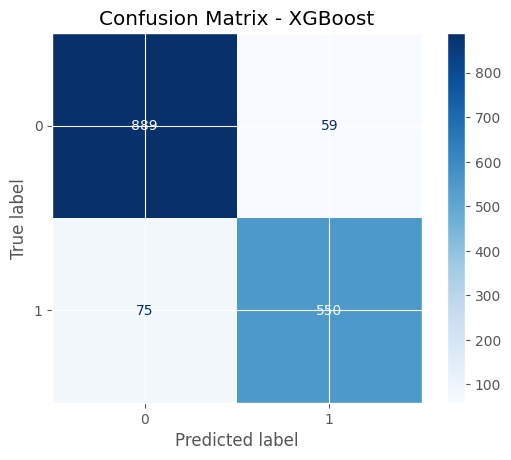

In [61]:
# Confusion Matrix
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm
)

disp.plot(cmap="Blues")
plt.title("Confusion Matrix - XGBoost")
plt.show()

##10.2. ROC Curve :

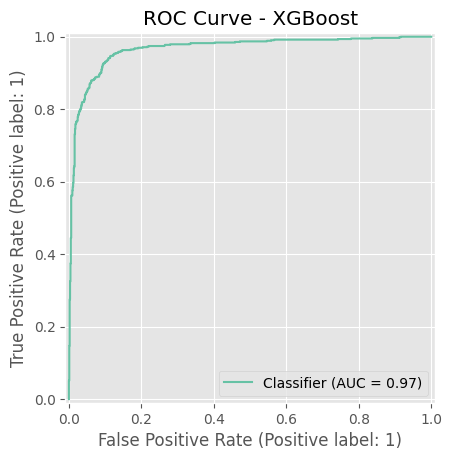

In [62]:
# ROC Curve
from sklearn.metrics import RocCurveDisplay
y_prob = best_model.predict_proba(X_test)[:,1]
RocCurveDisplay.from_predictions(
    y_test,
    y_prob
)

plt.title("ROC Curve - XGBoost")
plt.show()

## Observation :

- The detailed evaluation confirms that **XGBoost** is a highly effective model for lead conversion prediction. The model achieved an **Accuracy of 91.48%**, **Precision of 90%**, **Recall of 88%**, **F1-Score of 0.8914**, and a **ROC-AUC of 0.9661**, demonstrating strong overall classification performance.

- The **Classification Report** indicates that the model maintains a good balance between precision and recall for both converted and non-converted leads. The **Confusion Matrix** shows that the majority of leads were correctly classified (**889 True Negatives** and **550 True Positives**), with relatively few **False Positives (59)** and **False Negatives (75)**. Furthermore, the **ROC Curve** lies close to the upper-left corner with an **AUC of approximately 0.97**, confirming the model's excellent ability to distinguish between converted and non-converted leads across different decision thresholds.

- Overall, these evaluation metrics demonstrate that XGBoost provides accurate, reliable, and well-balanced predictions, making it the most suitable model for further optimization through hyperparameter tuning.

# 11. **Hyperparameter Tuning -**

Hyperparameter tuning is performed to optimize the performance of the selected XGBoost model.

Instead of using the default model parameters, a set of important hyperparameters is explored using **RandomizedSearchCV**. This approach efficiently searches different parameter combinations while reducing computational time compared to an exhaustive grid search.

The best parameter combination is selected based on cross-validation performance and then evaluated on the testing dataset.

##11.1. Hyperparameter Optimization :

In [63]:
# Hyperparameter Tuning using RandomizedSearchCV
from sklearn.model_selection import RandomizedSearchCV

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

xgb = XGBClassifier(
    random_state=42,
    eval_metric='logloss'
)

random_search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_grid,
    n_iter=10,
    scoring='f1',
    cv=5,
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train, y_train)

best_xgb = random_search.best_estimator_

print("Best Parameters:")
print(random_search.best_params_)

Best Parameters:
{'subsample': 0.8, 'n_estimators': 100, 'max_depth': 7, 'learning_rate': 0.05, 'colsample_bytree': 0.8}


##11.2. Evaluate Tuned Model :

In [64]:
# Evaluate Tuned XGBoost Model
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

y_pred_tuned = best_xgb.predict(X_test)
y_prob_tuned = best_xgb.predict_proba(X_test)[:,1]

print("Accuracy :", accuracy_score(y_test, y_pred_tuned))
print("Precision:", precision_score(y_test, y_pred_tuned))
print("Recall   :", recall_score(y_test, y_pred_tuned))
print("F1 Score :", f1_score(y_test, y_pred_tuned))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob_tuned))

Accuracy : 0.9148124602670057
Precision: 0.8991869918699187
Recall   : 0.8848
F1 Score : 0.8919354838709678
ROC-AUC  : 0.9664953586497891


##11.3. Compare Before & After Tuning :

In [65]:
# Performance Comparison
comparison = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC"],
    "Baseline": [
        accuracy_score(y_test, y_pred),
        precision_score(y_test, y_pred),
        recall_score(y_test, y_pred),
        f1_score(y_test, y_pred),
        roc_auc_score(y_test, y_prob)
    ],
    "Tuned": [
        accuracy_score(y_test, y_pred_tuned),
        precision_score(y_test, y_pred_tuned),
        recall_score(y_test, y_pred_tuned),
        f1_score(y_test, y_pred_tuned),
        roc_auc_score(y_test, y_prob_tuned)
    ]
})

comparison

,Metric,Baseline,Tuned
0,Accuracy,0.914812,0.914812
1,Precision,0.903120,0.899187
2,Recall,0.880000,0.884800
3,F1 Score,0.891410,0.891935
4,ROC-AUC,0.966104,0.966495


### Observation :

Hyperparameter tuning was successfully performed using **RandomizedSearchCV**, and the optimal parameter combination was identified as:

- **n_estimators:** 100
- **max_depth:** 7
- **learning_rate:** 0.05
- **subsample:** 0.8
- **colsample_bytree:** 0.8

The tuned XGBoost model achieved an **Accuracy of 91.48%**, **Precision of 89.92%**, **Recall of 88.48%**, **F1-Score of 0.8919**, and **ROC-AUC of 0.9665**.

Compared with the baseline model, hyperparameter tuning resulted in a **slight improvement in Recall, F1-Score, and ROC-AUC**, while Accuracy remained unchanged and Precision decreased marginally. Since the objective of this project is to accurately identify potential converted leads, the improvement in **F1-Score** indicates a better balance between Precision and Recall.

Therefore, the **tuned XGBoost model** is selected as the final model for feature importance analysis and business interpretation.

## 11.4. Enhanced Hyperparameter Optimization :

The initial hyperparameter tuning produced a strong XGBoost model with an **Accuracy of 91.48%**, **F1-Score of 0.8919**, and **ROC-AUC of 0.9665**. Although these results demonstrate excellent predictive performance, the improvement over the baseline model was relatively small. This suggests that the initial search explored only a limited number of hyperparameter combinations and may not have fully captured the model's optimal configuration.

To further improve the model's performance, a more comprehensive hyperparameter search is performed. The search space is expanded by including additional values for important parameters such as **max_depth**, **n_estimators**, **learning_rate**, **subsample**, **colsample_bytree**, **min_child_weight**, and **gamma**, while also increasing the number of random search iterations.

The objective of this enhanced optimization is to identify a better combination of hyperparameters that can improve the model's **Accuracy**, **F1-Score**, and **ROC-AUC**, while maintaining good generalization and reducing the risk of overfitting. The optimized model will then be evaluated and compared with the previously tuned model to determine the final model for deployment.

In [66]:
# Improved Hyperparameter Tuning using RandomizedSearchCV
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBClassifier

param_grid = {
    'n_estimators': [100, 200, 300, 400],
    'max_depth': [3, 4, 5, 6, 7, 8],
    'learning_rate': [0.01, 0.03, 0.05, 0.1],
    'subsample': [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.8, 0.9, 1.0],
    'min_child_weight': [1, 3, 5],
    'gamma': [0, 0.1, 0.2, 0.3]
}

xgb = XGBClassifier(
    random_state=42,
    eval_metric='logloss',
    use_label_encoder=False
)

random_search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_grid,
    n_iter=30,
    scoring='f1',
    cv=5,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

random_search.fit(X_train, y_train)

best_xgb = random_search.best_estimator_

print("Best Parameters:")
print(random_search.best_params_)

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best Parameters:
{'subsample': 0.8, 'n_estimators': 200, 'min_child_weight': 1, 'max_depth': 8, 'learning_rate': 0.03, 'gamma': 0.1, 'colsample_bytree': 0.7}


##11.5. Final Model Evaluation :

In [67]:
# Final Model Evaluation
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

y_pred_final = best_xgb.predict(X_test)
y_prob_final = best_xgb.predict_proba(X_test)[:, 1]

print("Accuracy :", accuracy_score(y_test, y_pred_final))
print("Precision:", precision_score(y_test, y_pred_final))
print("Recall   :", recall_score(y_test, y_pred_final))
print("F1 Score :", f1_score(y_test, y_pred_final))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob_final))

Accuracy : 0.9173553719008265
Precision: 0.8998384491114702
Recall   : 0.8912
F1 Score : 0.8954983922829582
ROC-AUC  : 0.9663586497890294


##11.6. Final Performance Comparison :

In [68]:
comparison_final = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC"],
    "Previous Tuned": [
        0.914812,
        0.899187,
        0.884800,
        0.891935,
        0.966495
    ],
    "Enhanced Tuned": [
        accuracy_score(y_test, y_pred_final),
        precision_score(y_test, y_pred_final),
        recall_score(y_test, y_pred_final),
        f1_score(y_test, y_pred_final),
        roc_auc_score(y_test, y_prob_final)
    ]
})

comparison_final

,Metric,Previous Tuned,Enhanced Tuned
0,Accuracy,0.914812,0.917355
1,Precision,0.899187,0.899838
2,Recall,0.884800,0.891200
3,F1 Score,0.891935,0.895498
4,ROC-AUC,0.966495,0.966359


### Observation :

To further improve the model's performance, an enhanced hyperparameter optimization was performed by expanding the search space and increasing the number of parameter combinations evaluated through **RandomizedSearchCV**.

The optimized XGBoost model identified the following best hyperparameters:

- **n_estimators:** 200
- **max_depth:** 8
- **learning_rate:** 0.03
- **subsample:** 0.8
- **colsample_bytree:** 0.7
- **min_child_weight:** 1
- **gamma:** 0.1

Compared to the previous tuned model, the enhanced optimization achieved a higher **Accuracy (91.74%)**, **Precision (89.98%)**, **Recall (89.12%)**, and **F1-Score (0.8955)**, while the **ROC-AUC (0.9664)** remained almost unchanged. The improvement in **Recall** and **F1-Score** indicates that the model became more effective at correctly identifying converted leads while maintaining balanced overall performance.

Therefore, the **enhanced tuned XGBoost model** is selected as the final model for feature importance analysis and business interpretation.

**Final Selected Model:** Enhanced Tuned XGBoost

# 12. **Feature Importance -**

Feature importance helps identify which variables contribute the most to the model's predictions. Since XGBoost is a tree-based ensemble algorithm, it can estimate the relative importance of each feature based on how frequently and effectively it is used to split the data during training.

Understanding feature importance provides valuable business insights by highlighting the key factors that influence whether a lead is likely to convert. These insights can support better marketing strategies, lead prioritization, and resource allocation.

##12.1. Important Features :

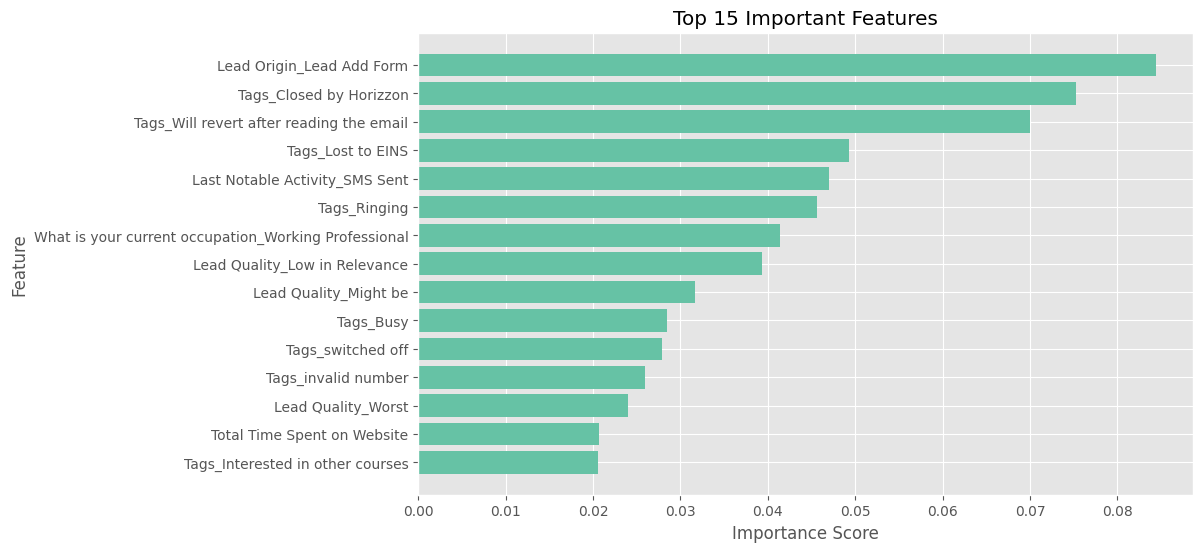

,Feature,Importance
17,Lead Origin_Lead Add Form,0.084439
118,Tags_Closed by Horizzon,0.075239
135,Tags_Will revert after reading the email,0.069965
126,Tags_Lost to EINS,0.049243
162,Last Notable Activity_SMS Sent,0.047002
130,Tags_Ringing,0.045635
114,What is your current occupation_Working Profes...,0.041399
142,Lead Quality_Low in Relevance,0.039338
143,Lead Quality_Might be,0.031684
117,Tags_Busy,0.028436


In [69]:
# Top 15 Important Features
import pandas as pd
import matplotlib.pyplot as plt

feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": best_xgb.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

top_features = feature_importance.head(15)

plt.figure(figsize=(10,6))
plt.barh(top_features["Feature"], top_features["Importance"])
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.title("Top 15 Important Features")
plt.gca().invert_yaxis()
plt.show()

top_features

## 12.2. Observation :

- The feature importance analysis highlights the variables that have the greatest influence on predicting lead conversion. Among all features, **Lead Origin (Lead Add Form)** emerged as the most influential predictor, indicating that the source from which a lead enters the system plays a significant role in determining conversion likelihood.

- Several **Tags** such as **Closed by Horizzon**, **Will revert after reading the email**, **Lost to EINS**, **Ringing**, **Busy**, **Switched Off**, **Invalid Number**, and **Interested in other courses** were also identified as highly important. These features capture the status and outcome of sales interactions, making them strong indicators of whether a lead is likely to convert.

- The model also identified **Last Notable Activity (SMS Sent)** and **Working Professional** as important predictors, suggesting that recent customer engagement and the lead's occupation positively influence conversion probability. Additionally, **Lead Quality** categories contributed significantly, reinforcing that the quality assessment assigned during the sales process is a valuable predictor of conversion.

- Among the numerical features, **Total Time Spent on Website** was one of the most important variables, indicating that leads who spend more time exploring the website generally exhibit higher purchase intent.

- Overall, the feature importance analysis demonstrates that **lead source, customer engagement, lead quality, communication history, and website activity** are the primary factors driving lead conversion. These insights can help businesses prioritize high-potential leads, improve marketing strategies, and allocate sales efforts more effectively.

# 13. **Business Insights -**

The machine learning model provides several valuable insights that can help improve the organization's lead management and conversion strategy.

- **Lead Source Matters:** Leads generated through **Lead Add Form** have a higher likelihood of conversion, indicating that investing in high-quality lead acquisition channels can improve overall sales performance.

- **Sales Interaction is a Strong Predictor:** Features related to sales follow-up, such as **Tags** (e.g., *Will revert after reading the email*, *Closed by Horizzon*, *Busy*, *Ringing*), significantly influence conversion outcomes. This highlights the importance of consistent customer communication and effective follow-up strategies.

- **Lead Quality Should Drive Prioritization:** The assigned **Lead Quality** plays a major role in predicting conversions. High-quality leads should be prioritized by the sales team to maximize conversion rates and improve resource utilization.

- **Customer Engagement Increases Conversion Probability:** Leads with higher **Total Time Spent on Website** and recent activities such as **SMS Sent** demonstrate stronger purchase intent. Monitoring user engagement can therefore help identify promising prospects.

- **Occupation Provides Additional Context:** Leads categorized as **Working Professionals** show meaningful predictive value, suggesting that customer profile information can further support targeted marketing campaigns.

# 14. **Conclusion -**

In this project, a complete machine learning pipeline was developed to predict whether a lead is likely to convert into a customer. The workflow included data understanding, exploratory data analysis, data preprocessing, feature engineering, model development, evaluation, hyperparameter tuning, and feature importance analysis.

Multiple classification algorithms were evaluated, including **Logistic Regression**, **Decision Tree**, **Random Forest**, and **XGBoost**. Among them, **XGBoost** consistently delivered the best performance. After performing enhanced hyperparameter optimization, the final model achieved:

- **Accuracy:** 91.74%

- **Precision:** 89.98%

- **Recall:** 89.12%

- **F1-Score:** 89.55%

- **ROC-AUC:** 96.64%

The feature importance analysis further revealed that **lead source, lead quality, customer engagement, sales interaction history, and website activity** are the most influential factors affecting lead conversion.

Overall, the developed lead scoring model can assist businesses in identifying high-potential leads, prioritizing sales efforts, improving marketing efficiency, and enabling data-driven decision-making. The resulting system provides a reliable and scalable approach for supporting customer acquisition and optimizing the lead conversion process.

# 15. **Model Serialization for Deployment -**

In [70]:
# 14. Model Export
import os
import joblib

# Create artifacts folder if it doesn't exist
os.makedirs("artifacts", exist_ok=True)

# Save trained model
joblib.dump(best_xgb, "artifacts/model.pkl")

# Save feature column names
joblib.dump(list(X_train.columns), "artifacts/feature_columns.pkl")
print("=" * 50)
print("✅ Model exported successfully!")
print("📁 Files created:")
print("   artifacts/model.pkl")
print("   artifacts/feature_columns.pkl")
print("=" * 50)

✅ Model exported successfully!
📁 Files created:
   artifacts/model.pkl
   artifacts/feature_columns.pkl


---
# **Thank You -**
This project demonstrates an end-to-end machine learning workflow for lead conversion prediction, from raw data preprocessing to model optimization and business interpretation. The developed solution can support organizations in improving lead prioritization and making more informed, data-driven sales and marketing decisions.